# E-commerce Sales & Customer Behavior Analysis

## Project Overview
This project analyzes transactional e-commerce sales data to identify revenue drivers, customer purchasing behavior, and geographic sales patterns.

## Business Objectives
- Identify top-performing products
- Analyze revenue trends over time
- Understand customer purchasing behavior
- Determine key geographic markets

## Tools Used
- Python (Pandas, NumPy)
- SQL
- Tableau

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (3).xlsx


In [3]:
df = pd.read_excel("Online Retail.xlsx")

## 3. Initial Data Exploration
This section examines dataset structure, column types, missing values, and potential data quality issues before cleaning.

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Missing Value Check

In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

### Initial Findings

- Dataset contains 541,909 rows and 8 columns.
- 1,454 rows have missing product descriptions.
- 135,080 rows are missing customer IDs.
- 5,268 duplicate rows exist.
- 9,288 transactions are cancelled orders.
- Quantity and UnitPrice contain suspicious values, including negatives and unusually large values.

In [12]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [13]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [14]:
(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [15]:
(df["Quantity"] == 0).sum()

np.int64(0)

In [16]:
(df["UnitPrice"] < 0).sum()

np.int64(2)

## 4. Data Cleaning

This section cleans missing values, removes cancelled transactions, handles invalid records, and creates new features for analysis.

### 4.1 Standardize Column Names

In [17]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df = df.rename(columns={
    "invoiceno": "invoice_no",
    "stockcode": "stock_code",
    "invoicedate": "invoice_date",
    "unitprice": "unit_price",
    "customerid": "customer_id",
    "dayofweek": "day_of_week"
})
df.columns

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country'],
      dtype='object')

### 4.2 Remove Missing Critical Values

In [18]:
#First check shape so we can compare before vs after
df.shape

(541909, 8)

In [19]:
#Store it if you want
rows_before = df.shape[0]

In [20]:
#Remove rows missing customer or description
df = df.dropna(subset=["customer_id", "description"])

In [21]:
df.shape

(406829, 8)

Removed rows with missing customer IDs or product descriptions because they prevent customer-level and product-level analysis.

### 4.3 Remove Duplicate Rows

In [22]:
df.duplicated().sum()

np.int64(5225)

In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

### 4.4 Remove Cancelled Orders

In [25]:
#Check cancellations
df["invoice_no"].astype(str).str.startswith("C").sum()

np.int64(8872)

In [26]:
#Remove them
df = df[~df["invoice_no"].astype(str).str.startswith("C")]

In [27]:
df["invoice_no"].astype(str).str.startswith("C").sum()

np.int64(0)

### 4.5 Remove Invalid Transactions
Remove:

negative quantity,
zero quantity,
zero price, and
negative price

In [28]:
df = df[(df["quantity"] > 0) & (df["unit_price"] > 0)]

In [29]:
(df["quantity"] <= 0).sum()

np.int64(0)

In [30]:
(df["unit_price"] <= 0).sum()

np.int64(0)

### Step 4.6 — Fix Data Types
Convert customer ID to integer.

In [31]:
df["customer_id"] = df["customer_id"].astype(int)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    392692 non-null  object        
 1   stock_code    392692 non-null  object        
 2   description   392692 non-null  object        
 3   quantity      392692 non-null  int64         
 4   invoice_date  392692 non-null  datetime64[ns]
 5   unit_price    392692 non-null  float64       
 6   customer_id   392692 non-null  int64         
 7   country       392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB


### Step 4.7 — Feature Engineering



In [33]:
#Create revenue

df["revenue"] = df["quantity"] * df["unit_price"]

In [34]:
#Convert dates
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

In [35]:
#Create time features
df["year"] = df["invoice_date"].dt.year
df["month"] = df["invoice_date"].dt.month
df["day"] = df["invoice_date"].dt.day
df["day_of_week"] = df["invoice_date"].dt.day_name()
df["hour"] = df["invoice_date"].dt.hour

### Step 4.8 — Final Cleaning Check

In [36]:
df.shape

(392692, 14)

In [37]:
df.isnull().sum()

,0
invoice_no,0
stock_code,0
description,0
quantity,0
invoice_date,0
unit_price,0
customer_id,0
country,0
revenue,0
year,0


In [38]:
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,year,month,day,day_of_week,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday,8


In [45]:
#Data size before vs after cleaning
rows_before = 541909
rows_after = df.shape[0]
rows_removed = rows_before - rows_after

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Total rows removed: {rows_removed}")

Rows before cleaning: 541909
Rows after cleaning: 392692
Total rows removed: 149217


### Data Cleaning Summary

The dataset was reduced from 541,909 to 392,692 rows after removing:
- Missing customer IDs and product descriptions  
- Cancelled transactions  
- Duplicate records  
- Invalid quantities and unit prices  

This ensures the dataset reflects only valid completed transactions for analysis.

## 5. Exploratory Data Analysis (EDA)

In this section, we analyze sales performance, customer behavior, product trends, and geographic distribution to extract business insights from the cleaned dataset.

### 5.1 Key Business KPIs

In [47]:
total_revenue = df["revenue"].sum()

total_orders = df["invoice_no"].nunique()

total_customers = df["customer_id"].nunique()

avg_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", avg_order_value)

Total Revenue: 8887208.894
Total Orders: 18532
Total Customers: 4338
Average Order Value: 479.56016047917115


### 5.2 Monthly Revenue Trend

In [48]:
monthly_sales = df.groupby("month")["revenue"].sum().reset_index()
monthly_sales

,month,revenue
0,1,568101.310
1,2,446084.920
2,3,594081.760
3,4,468374.331
4,5,677355.150
5,6,660046.050
6,7,598962.901
7,8,644051.040
8,9,950690.202
9,10,1035642.450


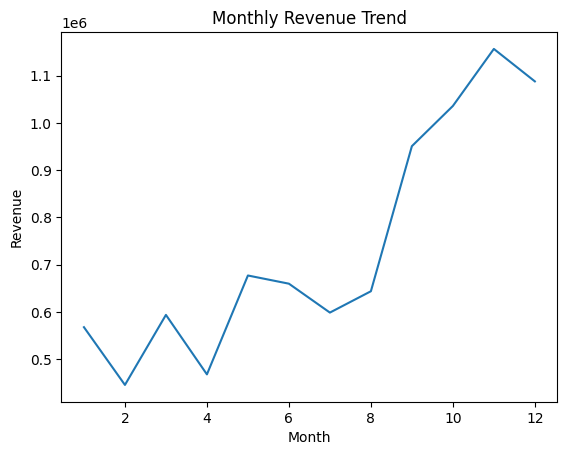

In [49]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_sales["month"], monthly_sales["revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### 5.3 Top 10 Products by Revenue

In [50]:
top_products = df.groupby("description")["revenue"].sum().sort_values(ascending=False).head(10)
top_products

,revenue
description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


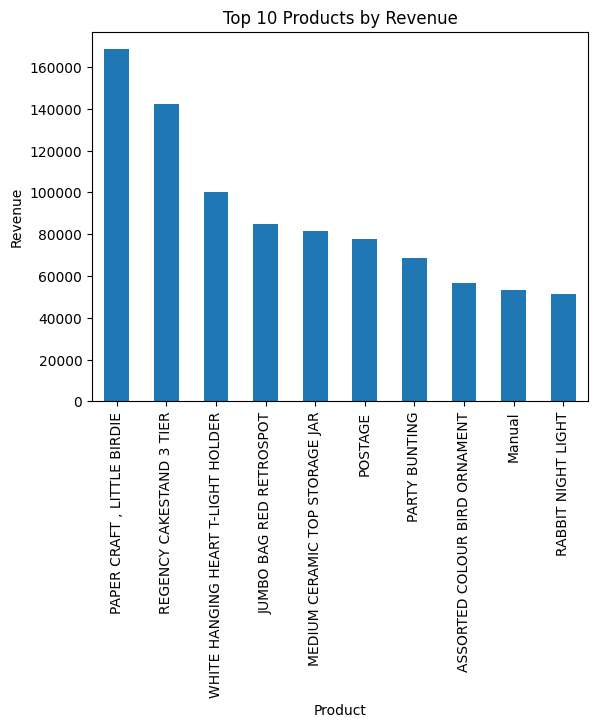

In [51]:
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

### 5.4 Revenue by Country

In [52]:
country_sales = df.groupby("country")["revenue"].sum().sort_values(ascending=False).head(10)
country_sales

,revenue
country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


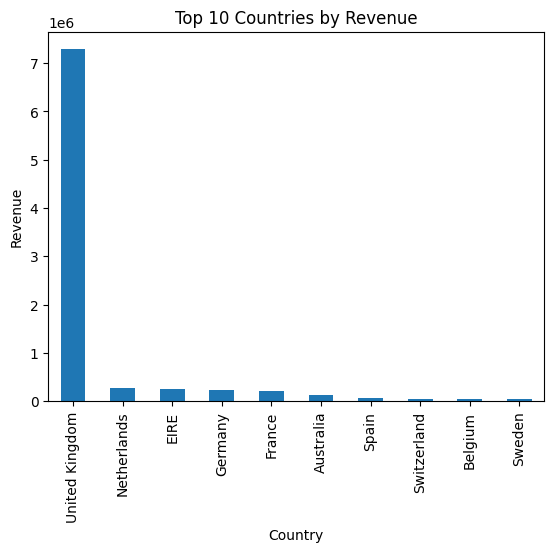

In [53]:
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

### 5.5 Top Customers by Revenue

In [54]:
top_customers = df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(10)
top_customers

,revenue
customer_id,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


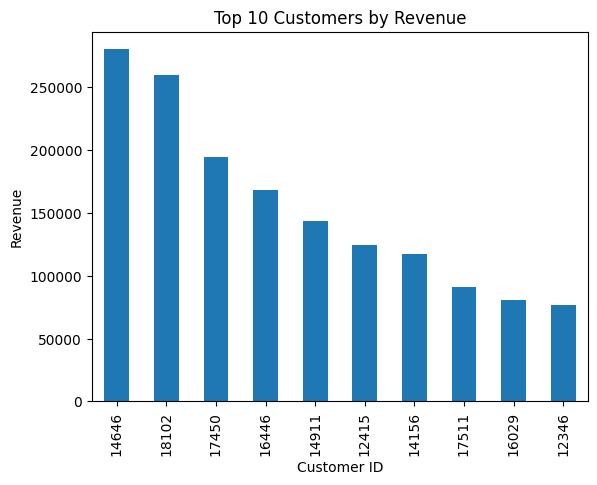

In [55]:
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

## 6. Initial Business Insights

- Revenue is driven by a small number of high-performing products.
- A small segment of customers contributes a large portion of total revenue.
- Certain countries dominate overall sales activity.
- Revenue shows variation across months, indicating seasonal patterns.

### 6.1 Revenue Concentration (Pareto Analysis)
We analyze whether a small number of customers or products generate most of the revenue.

In [56]:
#Customer revenue distribution
customer_revenue = df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)

customer_revenue.head()

,revenue
customer_id,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17


In [57]:
#% of revenue from top customers
top_10_customers_revenue = customer_revenue.head(10).sum()
total_revenue = df["revenue"].sum()

top_10_share = top_10_customers_revenue / total_revenue * 100
top_10_share

np.float64(17.301936168487234)

### 6.2 Basket Size (Items per Order)
We analyze how many items customers typically purchase per transaction.

In [58]:
#Items per invoice
basket_size = df.groupby("invoice_no")["quantity"].sum()

basket_size.head()

,quantity
invoice_no,
536365,40
536366,12
536367,83
536368,15
536369,3


In [59]:
#Average basket size
basket_size.mean()

np.float64(278.00571983595944)

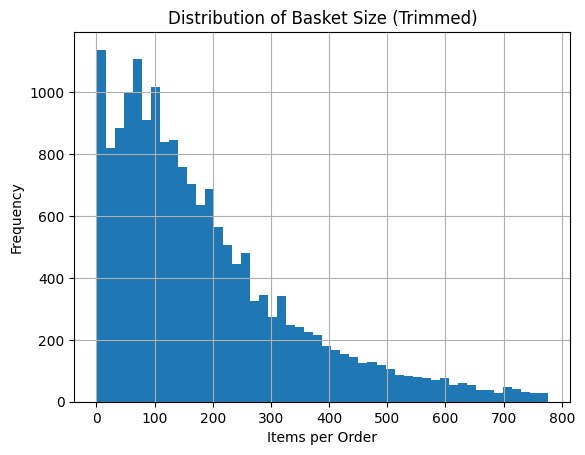

In [60]:
#Visualization
basket_size[basket_size < basket_size.quantile(0.95)].hist(bins=50)
plt.title("Distribution of Basket Size (Trimmed)")
plt.xlabel("Items per Order")
plt.ylabel("Frequency")
plt.show()

### 6.3 Revenue Distribution
We check how revenue is distributed across transactions.

In [61]:
df["revenue"].describe()

,revenue
count,392692.000000
mean,22.631500
std,311.099224
min,0.001000
25%,4.950000
50%,12.450000
75%,19.800000
max,168469.600000


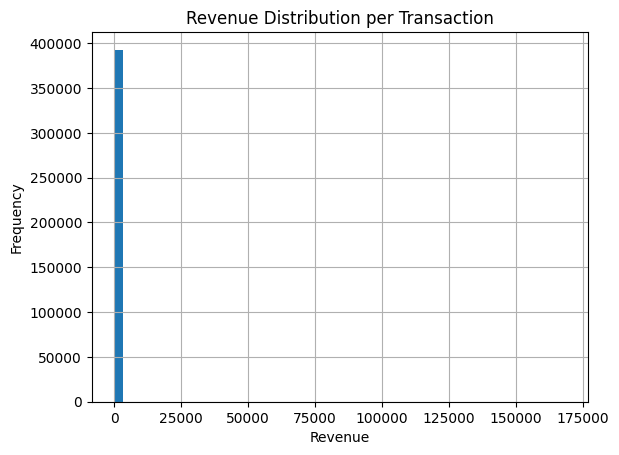

In [62]:
#Visualization
df["revenue"].hist(bins=50)
plt.title("Revenue Distribution per Transaction")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

### 6.4 Best Performing Countries vs Order Volume

We compare total revenue and number of orders by country to understand whether high revenue is driven by higher transaction volume or higher order value.

In [63]:
country_metrics = df.groupby("country").agg(
    total_revenue=("revenue", "sum"),
    total_orders=("invoice_no", "nunique")
).sort_values(by="total_revenue", ascending=False)

country_metrics.head(10)

,total_revenue,total_orders
country,,
United Kingdom,7285024.644,16646
Netherlands,285446.340,94
EIRE,265262.460,260
Germany,228678.400,457
France,208934.310,389
Australia,138453.810,57
Spain,61558.560,90
Switzerland,56443.950,51
Belgium,41196.340,98


### 6.5 Product Power Law (Revenue Concentration in Products)

We analyze whether a small number of products generate a disproportionate share of total revenue, which is commonly observed in retail datasets (Pareto principle / 80-20 rule).

In [64]:
product_revenue = df.groupby("description")["revenue"].sum().sort_values(ascending=False)

top_products_share = product_revenue.head(10).sum() / product_revenue.sum() * 100
top_products_share

np.float64(9.961025115519243)

## 7. SQL Analysis Layer

In [65]:
df.to_csv("ecommerce_cleaned.csv", index=False)

In [66]:
from google.colab import files
files.download("ecommerce_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
#Create database
import sqlite3

conn = sqlite3.connect("ecommerce.db")

In [71]:
#Load data into SQL table
df.to_sql("sales", conn, if_exists="replace", index=False)

392692

In [72]:
#Test query
pd.read_sql("SELECT * FROM sales LIMIT 5", conn)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,year,month,day,day_of_week,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday,8


In [73]:
#Total Revenue
pd.read_sql("""
SELECT SUM(revenue) AS total_revenue
FROM sales
""", conn)

,total_revenue
0,8.887209e+06


In [74]:
#Total Orders
pd.read_sql("""
SELECT COUNT(DISTINCT invoice_no) AS total_orders
FROM sales
""", conn)

,total_orders
0,18532


In [75]:
#Top 10 Products by Revenue
pd.read_sql("""
SELECT description,
       SUM(revenue) AS total_revenue
FROM sales
GROUP BY description
ORDER BY total_revenue DESC
LIMIT 10
""", conn)

,description,total_revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


In [76]:
#Top Customers
pd.read_sql("""
SELECT customer_id,
       SUM(revenue) AS total_spent
FROM sales
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 10
""", conn)

,customer_id,total_spent
0,14646,280206.02
1,18102,259657.30
2,17450,194390.79
3,16446,168472.50
4,14911,143711.17
5,12415,124914.53
6,14156,117210.08
7,17511,91062.38
8,16029,80850.84
9,12346,77183.60


In [77]:
#Monthly Revenue Trend
pd.read_sql("""
SELECT month,
       SUM(revenue) AS total_revenue
FROM sales
GROUP BY month
ORDER BY month
""", conn)

,month,total_revenue
0,1,568101.310
1,2,446084.920
2,3,594081.760
3,4,468374.331
4,5,677355.150
5,6,660046.050
6,7,598962.901
7,8,644051.040
8,9,950690.202
9,10,1035642.450


In [78]:
#Revenue by Country
pd.read_sql("""
SELECT country,
       SUM(revenue) AS total_revenue
FROM sales
GROUP BY country
ORDER BY total_revenue DESC
LIMIT 10
""", conn)

,country,total_revenue
0,United Kingdom,7.285025e+06
1,Netherlands,2.854463e+05
2,EIRE,2.652625e+05
3,Germany,2.286784e+05
4,France,2.089343e+05
5,Australia,1.384538e+05
6,Spain,6.155856e+04
7,Switzerland,5.644395e+04
8,Belgium,4.119634e+04
9,Sweden,3.836783e+04


In [80]:
#Customer Order Frequency
pd.read_sql("""
SELECT customer_id,
       COUNT(DISTINCT invoice_no) AS total_orders
FROM sales
GROUP BY customer_id
ORDER BY total_orders DESC
LIMIT 10
""", conn)

,customer_id,total_orders
0,12748,209
1,14911,201
2,17841,124
3,13089,97
4,14606,93
5,15311,91
6,12971,86
7,14646,73
8,16029,63
9,13408,62
